# Model Interpretation for Pretrained Deep Learning Models

This notebook demonstrates how to apply model interpretability algorithms on pretrained deep learning models (ResNet, VGG) using a handpicked image and visualizes the attributions for each pixel by overlaying them on the image.

The interpretation algorithms that we use in this notebook are `Integrated Gradients` (w/ and w/o noise tunnel),  `GradientShap`, `Occlusion`, and `LRP`. A noise tunnel smooths the attributions after adding gaussian noise to each input sample.

## Setup
Run this once per environment / kernel before executing the rest of the notebook.

In [ ]:
!pip install -q captum

Initial Imports:

In [ ]:
import torch
import torch.nn.functional as F

from PIL import Image

import os
import json
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import torchvision
from torchvision import models
from torchvision import transforms
from torchvision.models import ResNet18_Weights, VGG16_Weights

from captum.attr import IntegratedGradients
from captum.attr import GradientShap
from captum.attr import LRP
from captum.attr import Occlusion
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz
from captum.attr._utils.lrp_rules import EpsilonRule, GammaRule, Alpha1_Beta0_Rule

## 1. Loading the model and the dataset


Load pretrained Resnet model and set it to eval mode.

In [3]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model = model.eval()

Download the list of classes / labels for ImageNet dataset and read them into the memory.

In [4]:
!wget -nv -P $HOME/.torch/models https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json

2026-02-23 14:08:40 URL:https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json [35363/35363] -> "/Users/felix/.torch/models/imagenet_class_index.json.4" [1]


In [5]:
labels_path = os.getenv("HOME") + '/.torch/models/imagenet_class_index.json'
with open(labels_path) as json_data:
    idx_to_labels = json.load(json_data)

Define transformers and normalizing functions for the image.
Also load an image from the `img/resnet/` folder that will be used for interpretation purposes.

In [6]:
!mkdir -p img/segmentation
!wget -nv -O img/segmentation/classify-image.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/6/62/Swan_-_Flickr_-_JOHN_K_THORNE.jpg/1280px-Swan_-_Flickr_-_JOHN_K_THORNE.jpg

2026-02-23 14:08:41 URL:https://upload.wikimedia.org/wikipedia/commons/thumb/6/62/Swan_-_Flickr_-_JOHN_K_THORNE.jpg/1280px-Swan_-_Flickr_-_JOHN_K_THORNE.jpg [280928/280928] -> "img/segmentation/classify-image.jpg" [1]


In [7]:
transform = transforms.Compose([
 transforms.Resize(256),
 transforms.CenterCrop(224),
 transforms.ToTensor()
])

transform_normalize = transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
 )

img = Image.open('img/segmentation/classify-image.jpg')

transformed_img = transform(img)

input = transform_normalize(transformed_img)
input = input.unsqueeze(0)

Predict the class of the input image.

In [8]:
output = model(input)
output = F.softmax(output, dim=1)
prediction_score, pred_label_idx = torch.topk(output, 1)

pred_label_idx.squeeze_()
predicted_label = idx_to_labels[str(pred_label_idx.item())][1]
print('Predicted:', predicted_label, '(', prediction_score.squeeze().item(), ')')


Predicted: goose ( 0.5506605505943298 )


## 2. Gradient-based attribution

Let's compute attributions using Integrated Gradients and visualize them on the image. Integrated gradients computes the integral of the gradients of the output of the model for the predicted class `pred_label_idx` with respect to the input image pixels along the path from the black image to our input image.

In [9]:
integrated_gradients = IntegratedGradients(model)
attributions_ig = integrated_gradients.attribute(input, target=pred_label_idx, n_steps=200)

Let's visualize the image and corresponding attributions by overlaying the latter on the image.

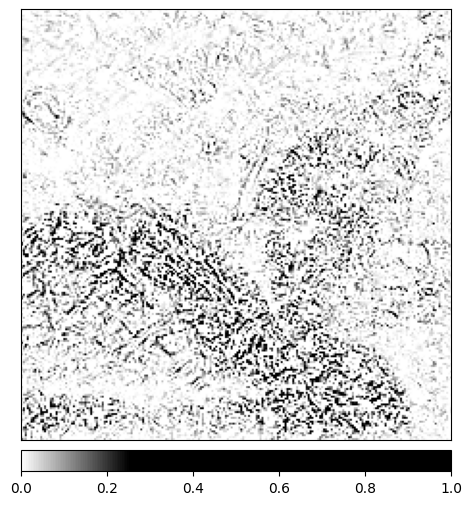

In [10]:
default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#000000'),
                                                  (1, '#000000')], N=256)

_ = viz.visualize_image_attr(np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                             method='heat_map',
                             cmap=default_cmap,
                             show_colorbar=True,
                             sign='positive',
                             outlier_perc=1)

Let us compute attributions using Integrated Gradients and smooth them across multiple images generated by a <em>noise tunnel</em>. The latter adds gaussian noise, with a standard deviation equal to one, ten times (nt_samples=10) to the input. Ultimately, noise tunnel smooths the attributions across `nt_samples` noisy samples using the `smoothgrad_sq` technique. `smoothgrad_sq` represents the mean of the squared attributions across `nt_samples` samples.

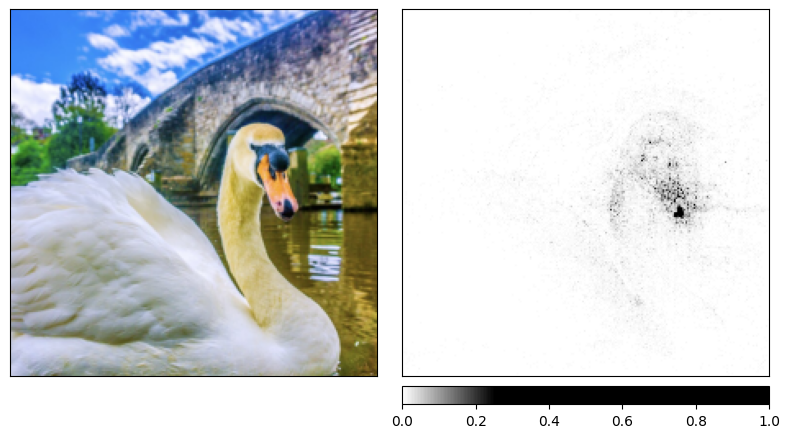

In [11]:
noise_tunnel = NoiseTunnel(integrated_gradients)

attributions_ig_nt = noise_tunnel.attribute(input, nt_samples=10, nt_type='smoothgrad_sq', target=pred_label_idx)
_ = viz.visualize_image_attr_multiple(np.transpose(attributions_ig_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      cmap=default_cmap,
                                      show_colorbar=True)


Finally, let us use `GradientShap`, a linear explanation model which uses a distribution of reference samples (in this case two images) to explain predictions of the model. It computes the expectation of gradients for an input which was chosen randomly between the input and a baseline. The baseline is also chosen randomly from a given baseline distribution.

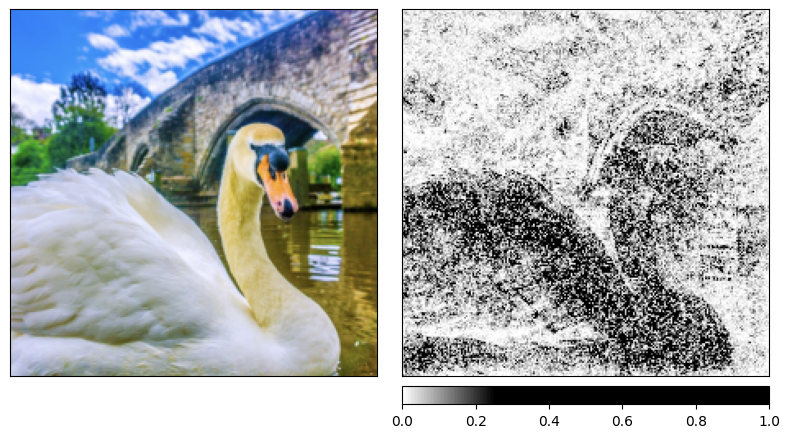

In [12]:
torch.manual_seed(0)
np.random.seed(0)

gradient_shap = GradientShap(model)

# Defining baseline distribution of images
rand_img_dist = torch.cat([input * 0, input * 1])

attributions_gs = gradient_shap.attribute(input,
                                          n_samples=50,
                                          stdevs=0.0001,
                                          baselines=rand_img_dist,
                                          target=pred_label_idx)
_ = viz.visualize_image_attr_multiple(np.transpose(attributions_gs.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True)


## 3. Occlusion-based attribution

Now let us try a different approach to attribution. We can estimate which areas of the image are critical for the classifier's decision by occluding them and quantifying how the decision changes.

We run a sliding window of size 15x15 (defined by `sliding_window_shapes`) with a stride of 8 along both image dimensions (defined by `strides`). At each location, we occlude the image with a baseline value of 0 which corresponds to a gray patch (defined by `baselines`).

**Note:** this computation might take more than one minute to complete, as the model is evaluated at every position of the sliding window.

In [13]:
occlusion = Occlusion(model)

attributions_occ = occlusion.attribute(input,
                                       strides = (3, 8, 8),
                                       target=pred_label_idx,
                                       sliding_window_shapes=(3,15, 15),
                                       baselines=0)


Let us visualize the attribution, focusing on the areas with positive attribution (those that are critical for the classifier's decision):

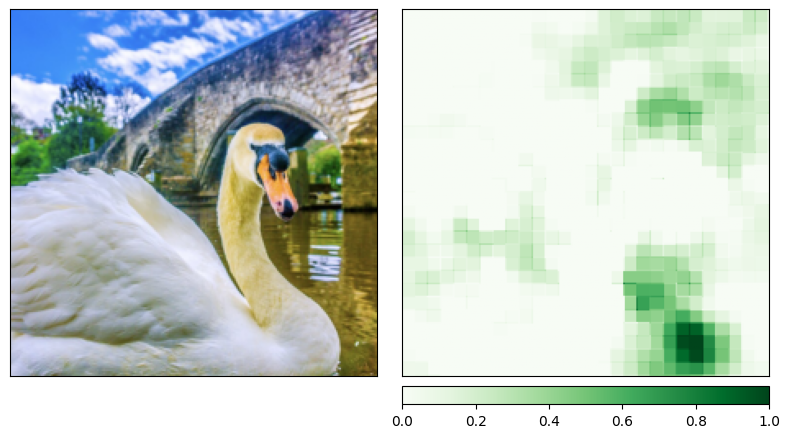

In [14]:
_ = viz.visualize_image_attr_multiple(np.transpose(attributions_occ.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      show_colorbar=True,
                                      outlier_perc=2)


The upper part of the goose, especially the beak, seems to be the most critical for the model to predict this class.

We can verify this further by occluding the image using a larger sliding window:

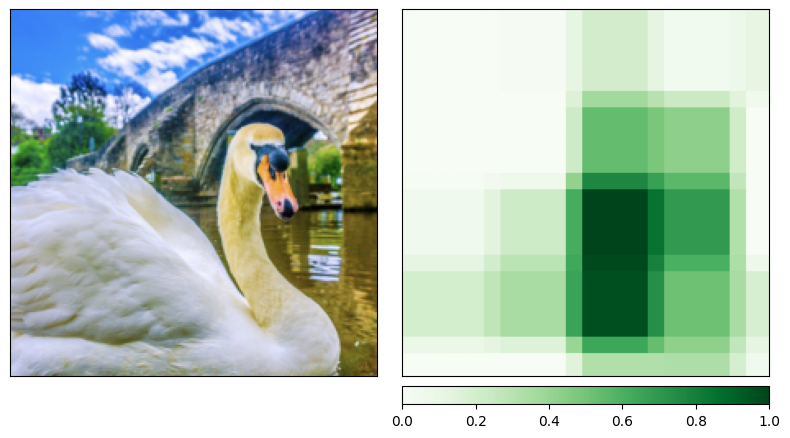

In [15]:
occlusion = Occlusion(model)

attributions_occ = occlusion.attribute(input,
                                       strides = (3, 50, 50),
                                       target=pred_label_idx,
                                       sliding_window_shapes=(3,60, 60),
                                       baselines=0)

_ = viz.visualize_image_attr_multiple(np.transpose(attributions_occ.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      show_colorbar=True,
                                      outlier_perc=2)

 ## 4. LRP-based attribution

Now let's try a different approach called Layer-Wise Relevance Propagation (LRP). It uses a backward propagation mechanism applied sequentially to 
all layers of the model, to see which neurons contributed to the output. The output score of LRP represents the relevance, decomposed into values for each layer. 
The decomposition is defined by rules that may vary for each layer. 

Initially, we apply a direct implementation of LRP attribution. The default Epsilon-Rule is used for each layer. 

Note: We use the VGG16 model instead here since the default rules for LRP are not currently fine-tuned for ResNet.

In [16]:
model = models.vgg16(weights=VGG16_Weights.DEFAULT)
model.eval()
lrp = LRP(model)

attributions_lrp = lrp.attribute(input.requires_grad_(True), target=pred_label_idx)

Let us visualize the attribution, focusing on the areas with positive attribution (those that are critical for the classifier's decision):

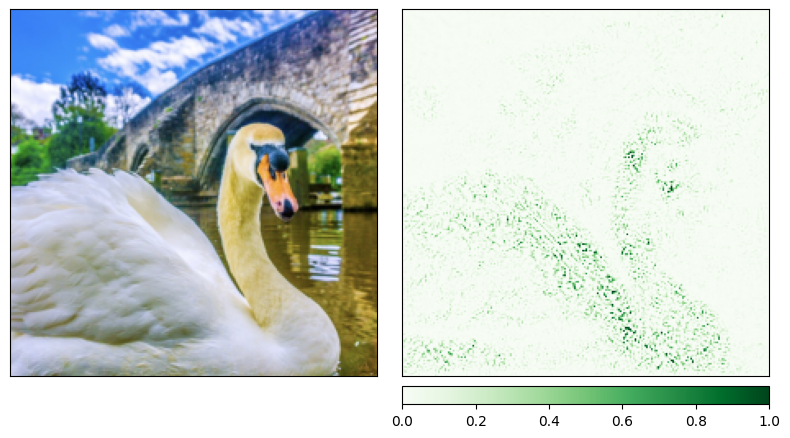

In [17]:
_ = viz.visualize_image_attr_multiple(np.transpose(attributions_lrp.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      show_colorbar=True,
                                      outlier_perc=2)

Now let's play around with changing the propagation rules for the various layers. This is a crucial step to get expressive heatmaps. Captum currently has the following propagation rules implemented: LRP-Epsilon, LRP-0, LRP-Gamma, LRP-Alpha-Beta, and the Identity-Rule. 

In the next steps, we list all the layers of VGG16 and assign a rule to each one. 

Note: A reference for recommmendations on how to set the rules can be found in *[Towards best practice in explaining neural network decisions with LRP](https://arxiv.org/abs/1910.09840)*.

In [18]:
layers = list(model._modules["features"]) + list(model._modules["classifier"])
num_layers = len(layers)

for idx_layer in range(1, num_layers):
    if idx_layer <= 16:
        setattr(layers[idx_layer], "rule", GammaRule())
    elif 17 <= idx_layer <= 30:
        setattr(layers[idx_layer], "rule", EpsilonRule())
    elif idx_layer >= 31:
        setattr(layers[idx_layer], "rule", EpsilonRule(epsilon=0))

lrp = LRP(model)
attributions_lrp = lrp.attribute(input, 
                                target=pred_label_idx)

Let us visualize the new attribution. As we can see in the generated output image, the heatmap shows clearly positive attributions forthe beak of the swan.

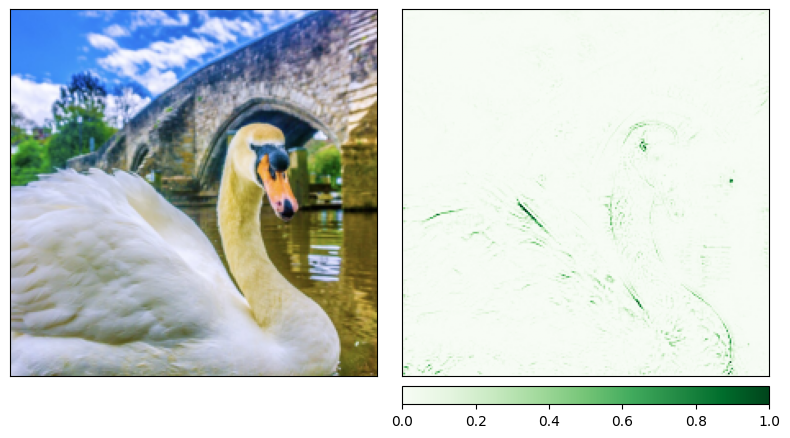

In [19]:
_ = viz.visualize_image_attr_multiple(np.transpose(attributions_lrp.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      show_colorbar=True,
                                      outlier_perc=2)

This notebook was adapted from the following tutorial: https://captum.ai/tutorials/TorchVision_Interpret. It is licensed under the BSD 3-Clause License, reproduced below.

---

BSD 3-Clause License

Copyright (c) 2019, PyTorch team
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be used to endorse or promote products derived from
  this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

---

The image used in this notebook, ["Swan - Flickr - JOHN K THORNE.jpg"](https://commons.wikimedia.org/wiki/File:Swan_-_Flickr_-_JOHN_K_THORNE.jpg), is by *JOHN K THORNE* and is available via Wikimedia Commons (original source: [Flickr](https://www.flickr.com/photos/seattlecamera/54566209308/)). License: [CC0 1.0 Universal Public Domain Dedication](https://creativecommons.org/publicdomain/zero/1.0/deed.en). No changes were made to the image.